In [16]:
# !pip install numba
# ! pip install jax

In [17]:
# import sys
# import os

# # Add the directory containing instruments.py to the Python path
# custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
# sys.path.append(custom_module_path)

# import instruments as inst
# import numpy as np
# import json

from pyPolCal.csv_tools import read_csv, read_csv_VAMPIRES
from pyPolCal.utils import * 
from pyPolCal.fitting import minimize_system_mueller_matrix, model, process_dataset, process_model, update_p0, update_system_mm, logl
from pyPolCal.plotting import plot_data_and_model
from pyPolCal.constants import wavelength_bins # all CHARIS wavelength bins
from pyMuellerMat.physical_models.charis_physical_models import * # Joost 't Hart 2021 physical models
import numpy as np
import json
from importlib.resources import files

In [18]:
# register an elliptical retarder/diattenuator

from pyPolCal.mm_registry import register_mm_function
from pyMuellerMat.common_mm_functions import elliptical_retarder_function, diattenuator_retarder_function


@register_mm_function()
def elliptical_retarder_diattenuator_function(phi_h=0, phi_r=0, phi_45=0, epsilon=0):
    mm_elliptical_retarder = elliptical_retarder_function(phi_h=phi_h, phi_r=phi_r, phi_45=phi_45)
    mm_diattenuator = diattenuator_retarder_function(epsilon=epsilon)
    combined_mm = mm_elliptical_retarder @ mm_diattenuator
    return combined_mm


Mueller matrix function 'elliptical_retarder_diattenuator_function' is already registered. Overwriting.


# Step 1: Setting up initial information

In [19]:
# Data path for processed csv
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table_pyPolCal_version.csv"
wavelengths = [
            # 610, 
            # 670, 
            # 720, 
            760
            ]
obs_modes = [
            # "MBI", 
            # "MBI", 
            # "MBI", 
            "MBI"
            ]
previous_fits_directory = "/home/rebeccaz/Github/pyPolCal/pyPolCal/VAMPIRES/elliptical_retardance/data/previous_fits/"
save_fits_directory = "/home/rebeccaz/Github/pyPolCal/pyPolCal/VAMPIRES/elliptical_retardance/results/"
em_gains = [
    # 1.230573943788524, 
    # 1.1946169522853136, 
    # 1.1968557857131294, 
    1.0798052820150867
    ]

# Step 2: Performing fits iteratively by wavelength - first broadband then MBI

{'dichroic': {'phi': 3.800937937993656e-07, 'epsilon': 0.015051115678248555, 'theta': -10.0}, 'flc': {'phi': 3.142039565979661, 'delta_theta': 4.9999999109842665}, 'optics': {'phi_h': 1.6955249325461543, 'epsilon': 1.5430894781636849e-12, 'theta': -6.282285946934403}, 'image_rotator': {'phi_h': 3.271764997945918}, 'hwp': {'phi': 2.8134074350995815, 'delta_theta': 4.999999988832821}, 'lp': {'theta': 1.2154357639797413}}
HWP retardance: 3.015928947446201
[[0.50893359 0.50847561 0.0215859  0.        ]
 [0.50893359 0.50847561 0.0215859  0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]
logl value: 10659.84089857907


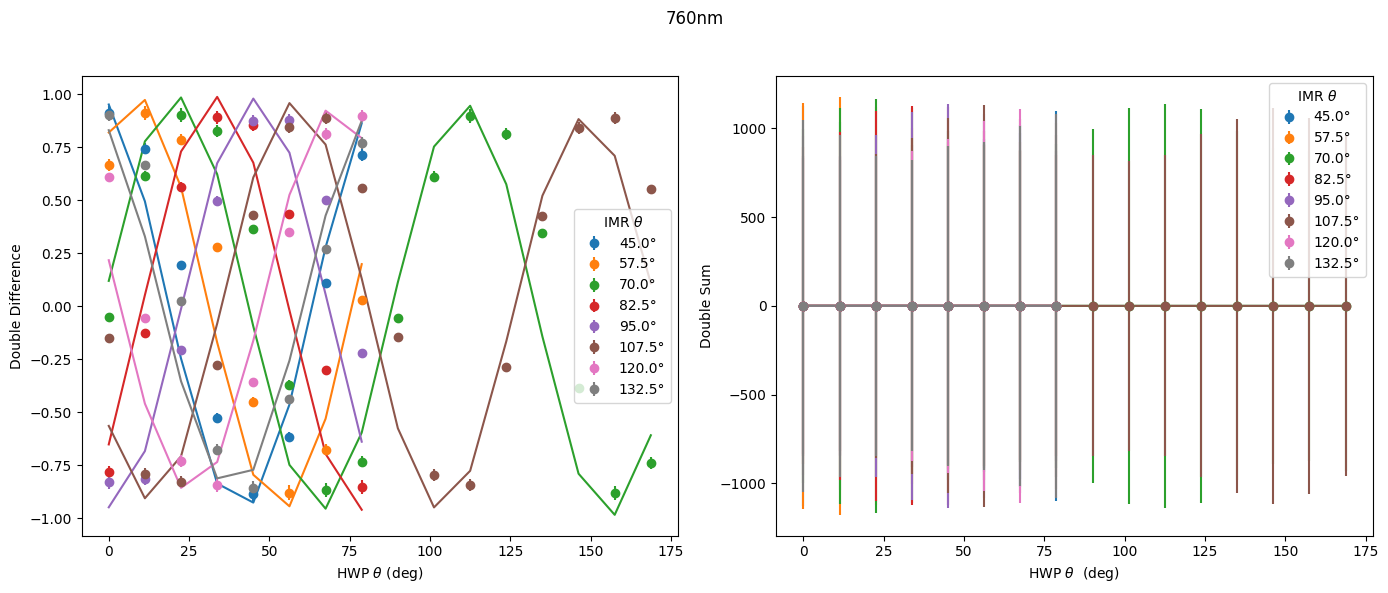

Before p0: {'dichroic': {'phi': np.float64(3.800937937993656e-07), 'epsilon': 0.015051115678248555, 'theta': 0}, 'flc': {'phi': 3.142039565979661, 'delta_theta': 4.9999999109842665}, 'optics': {'phi_h': np.float64(1.6955249325461543), 'phi_r': 0, 'phi_45': 0, 'epsilon': 1.5430894781636849e-12, 'theta': 0}, 'image_rotator': {'phi_h': np.float64(3.271764997945918), 'phi_r': 0, 'phi_45': 0}, 'hwp': {'phi': 3.015928947446201, 'delta_theta': 4.999999988832821}, 'lp': {'theta': 1.2154357639797413}}


In [ ]:
# Defining wavelength
for i, wavelength in enumerate(wavelengths):
    interleaved_values, interleaved_stds, configuration_list = read_csv_VAMPIRES(file_path, 
        obs_mode = obs_modes[i], 
        obs_filter = wavelength, 
        flc_a_theta = 0, 
        flc_b_theta = 43)

    # if obs_modes[i] == "IPOL":
    #   filename = previous_fits_directory + wavelength + "nm_ten_percent_IMR_offset_or_IMR_and_HWP_constraints_FLC_0_to_43_dichroic_ten_degree_constraints.txt"
    
    filename = "/home/rebeccaz/Github/pyPolCal/pyPolCal/VAMPIRES/elliptical_retardance/data/previous_fits/760nm_ten_percent_retardance_constraints_dichroic_theta_0_optics_theta_0_pm_15_reduced_errors.txt"

    # Using closest broadband files    
    with open(filename, "r") as f:
        past_fit = json.load(f)
    print(past_fit)

    theta_pol = past_fit["lp"]["theta"]
    delta_HWP = past_fit["hwp"]["phi"] 
    offset_HWP = past_fit["hwp"]["delta_theta"]
    delta_derot = past_fit["image_rotator"]["phi_h"] 
    delta_opts = past_fit["optics"]["phi_h"]
    epsilon_opts = past_fit["optics"]["epsilon"]
    rot_opts = past_fit["optics"]["theta"]
    delta_dichroic = past_fit["dichroic"]["phi"]
    epsilon_dichroic = past_fit["dichroic"]["epsilon"]
    rot_dichroic = past_fit["dichroic"]["theta"]
    delta_FLC = past_fit["flc"]["phi"] 
    rot_FLC = past_fit["flc"]["delta_theta"]
    em_gain = em_gains[i] # from EM gain measurements

    # Changing the HWP retardance
    delta_HWP = 0.48 * 2 * np.pi

    print("HWP retardance: " + str(delta_HWP))

    # NOTE: Components must be listed downstream to upstream
    # Define the instrument configuration as a system dictionary
    system_dict = {
        "components": {
            "wollaston": {
                "type": "wollaston_prism_function",
                "properties": {"beam": "o", "transmission_ratio": em_gain},
            },
            "dichroic": {
                "type": "diattenuator_retarder_function",
                "properties": {'phi': delta_dichroic, 
                    'epsilon': epsilon_dichroic, 
                    # 'theta': rot_dichroic
                    'theta': 0},
            },
            "flc": {
                "type": "general_retarder_function",
                "properties": {"phi": delta_FLC, "theta": 0, "delta_theta": rot_FLC},
            },
            "optics": {
                "type": "elliptical_retarder_diattenuator_function",
                "properties": {'phi_h': delta_opts,
                               'phi_r': 0,
                               'phi_45': 0,
                               'epsilon': epsilon_opts, 
                               'theta': rot_opts,
                               },
            },
            "image_rotator": {
                "type": "elliptical_retarder_function",
                "properties": {"phi_h": delta_derot, 
                                "phi_r": 0,
                                "phi_45": 0,
                                "theta": 0, 
                                "delta_theta": 0},
            },
            "hwp": {
                "type": "general_retarder_function",
                "properties": {"phi":  delta_HWP, "theta": 0, "delta_theta": offset_HWP},
            },
            "lp": {
                "type": "general_linear_polarizer_function_with_theta",
                "properties": {"theta": theta_pol},
            },
        }
    }

    bounds = [ 
    (0, 2 * np.pi), # dichroic_retardance
    (0, 1), # dichroic_diattenuation
    (-45, 45), # dichroic_rotation_angle 
    (0.4 * 2 * np.pi, 0.6 * 2 * np.pi),  # flc_phi
    (-5, 5),  # flc_delta_theta
    (0, 2 * np.pi),  # optics_phi_h
    (0, 0),  # optics_phi_r (fixed)
    (0, 0),  # optics_phi_45 (fixed)
    (0, 1),  # optics_epsilon
    (-10, 10),  # optics_theta
    (delta_derot - (delta_derot * 0.1), delta_derot + (delta_derot * 0.1)),  # image_rotator_phi_h
    (0, 0),  # image_rotator_phi_r (fixed)
    (0, 0),  # image_rotator_phi_45 (fixed)
    (delta_HWP - (delta_HWP * 0.1), delta_HWP + (delta_HWP * 0.1)),  # hwp_phi
    (-5, 5),  # hwp_delta_theta
    (-5, 5),  # lp_theta
    ]

    # Turn dictionary into matrix
    system_mm = generate_system_mueller_matrix(system_dict)
    print(system_mm.evaluate())

    # Set-up for p0
    p0 = {
    # "wollaston": {"transmission_ratio": em_gain}, 
    "dichroic": {"phi": np.abs(delta_dichroic), 
                 "epsilon": epsilon_dichroic, 
                 # "theta": rot_dichroic
                 "theta": 0
                 },
    "flc": {"phi": delta_FLC, "delta_theta": rot_FLC},
    "optics": {"phi_h": np.abs(delta_opts), # retardance for Q
               "phi_r": 0,
               "phi_45": 0,
               "epsilon": epsilon_opts, 
               # "theta": rot_opts
               "theta": 0
               },
    "image_rotator": {
                    "phi_h": np.abs(delta_derot), # retardance for Q
                    "phi_r": 0, # retardance for V
                    "phi_45": 0, # retardance for U
                    # "delta_theta": 0
                    },
    "hwp": {"phi": delta_HWP, "delta_theta": offset_HWP},
    "lp": {"theta": theta_pol}
    }

    # Adding p0
    p0_values, p0_keywords = parse_configuration(p0)
    if len(bounds) != len(p0_values):
        raise ValueError(f"len(bounds)={len(bounds)} but len(p0_values)={len(p0_values)}. p0 order: {p0_keywords}")
    s_in = np.array([1, 0, 0, 0])
    logl_value = logl(p0_values, p0_keywords, system_mm, interleaved_values, configuration_list,
        s_in=s_in, errors=interleaved_stds,
        # logl_function=None, 
        process_dataset=process_dataset, process_errors=process_errors, 
        process_model=process_model)
    print("logl value: " + str(logl_value))

    # Plotting intial plot
    updated_system_mm = update_system_mm(p0_values, p0_keywords, system_mm)
    # model(p, system_parameters, system_mm, configuration_list, s_in=None, 
    #         process_model = None):
    current_model = model(p0_values, p0_keywords, system_mm, configuration_list, 
        process_model = process_model)

    plot_data_and_model(interleaved_values, current_model, 
        configuration_list,  interleaved_stds=interleaved_stds, wavelength = wavelength)

    # Iterative Fitting
    # Unpolarized light for s_in as there is LP in the system already
    s_in = np.array([1, 0, 0, 0])

    # Counters for iterative fitting
    iteration = 1
    previous_logl_value = 1000000
    new_logl_value = 0

    while abs(previous_logl_value - new_logl_value) > 0.01 * abs(previous_logl_value):
        print("Before p0: " + str(p0))
        if iteration > 1: 
            previous_logl_value = new_logl_value
        result, new_logl_value = minimize_system_mueller_matrix(p0, system_mm, 
            interleaved_values, configuration_list, errors=interleaved_stds, s_in = s_in,
            process_dataset = process_dataset, 
            process_errors = process_errors, 
            process_model = process_model, bounds = bounds)
        
        # Print statements
        print("Iteration #: " + str(iteration))
        print("logl_value: " + str(new_logl_value))
        print("Best Fit Parameters: " + str(result.x))

        # Making a plot
        updated_system_mm = update_system_mm(result.x, p0_keywords, system_mm)
        current_model = model(result.x, p0_keywords, updated_system_mm, configuration_list, 
        process_model = process_model)

        save_path = save_fits_directory + str(wavelength) + "nm_ten_percent_retardance_constraints_dichroic_theta_0_to_15_optics_theta_0_reduced_errors.png"
        plot_data_and_model(interleaved_values, interleaved_stds, current_model, 
            configuration_list, wavelength = wavelength, save_path = save_path)

        # Updating p0 for next time
        update_p0(p0, result.x)
        print("After p0: " + str(p0))

        iteration += 1

        filename = save_fits_directory + str(wavelength) + "nm_ten_percent_retardance_constraints_dichroic_theta_0_to_15_optics_theta_0_reduced_errors.txt"
        with open(filename, 'w') as f:
            json.dump(p0, f, indent=4)

# Printing table of final values

In [ ]:
# Load p0 from .txt files for each wavelength and print a summary table (retardances in waves)
import pandas as pd
import json
import numpy as np
def radians_to_waves(rad):
    return rad / (2 * np.pi)
 
summary_rows = []
param_names = [
    'wavelength',
    'dichroic_phi (waves)', 'dichroic_epsilon', 'dichroic_theta',
    'flc_phi (waves)', 'flc_delta_theta',
    'optics_phi (waves)', 'optics_epsilon', 'optics_theta',
    'image_rotator_phi (waves)',
    'hwp_phi (waves)', 'hwp_delta_theta',
    'lp_theta'
 ]
 
# Directory and file pattern for saved p0 files
save_fits_directory = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/data_files/produced/FLC_0_to_43_ten_percent_retardance_constraints_dichroic_theta_0_to_15_optics_theta_0_reduced_errors/"
file_pattern = "{wavelength}nm_ten_percent_retardance_constraints_dichroic_theta_0_to_15_optics_theta_0_reduced_errors.txt"
 
wavelengths = [
              # 610, 
              # 670, 
              # 720, 
               760]

for wl in wavelengths:
    filename = save_fits_directory + file_pattern.format(wavelength=wl)
    try:
        with open(filename, 'r') as f:
            p0 = json.load(f)
        row = {
            'wavelength': wl,
            'dichroic_phi (waves)': radians_to_waves(p0['dichroic']['phi']),
            'dichroic_epsilon': p0['dichroic']['epsilon'],
            'dichroic_theta': p0['dichroic']['theta'],
            'flc_phi (waves)': radians_to_waves(p0['flc']['phi']),
            'flc_delta_theta': p0['flc']['delta_theta'],
            'optics_phi (waves)': radians_to_waves(p0['optics']['phi']),
            'optics_epsilon': p0['optics']['epsilon'],
            'optics_theta': p0['optics']['theta'],
            'image_rotator_phi (waves)': radians_to_waves(p0['image_rotator']['phi']),
            'hwp_phi (waves)': radians_to_waves(p0['hwp']['phi']),
            'hwp_delta_theta': p0['hwp']['delta_theta'],
            'lp_theta': p0['lp']['theta']
        }
        summary_rows.append(row)
    except Exception as e:
        print(f"Could not load {filename}: {e}")
 
df = pd.DataFrame(summary_rows, columns=param_names)
print("\nSummary of final p0 values for each wavelength (retardances in waves):")
print(df.to_string(index=False))


Summary of final p0 values for each wavelength (retardances in waves):
 wavelength  dichroic_phi (waves)  dichroic_epsilon  dichroic_theta  flc_phi (waves)  flc_delta_theta  optics_phi (waves)  optics_epsilon  optics_theta  image_rotator_phi (waves)  hwp_phi (waves)  hwp_delta_theta  lp_theta
        760              0.000095          0.014794       -8.771212         0.500097         4.950318            0.270025    6.979099e-08     -6.335604                   0.520681         0.447624         4.999087   1.13736
